<a href="https://colab.research.google.com/github/Fata-Haidar/244107020108-Pembelajaran-Mesin/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library**

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**1. Identifikasi Variabel Fitur dan Target**

Dataset yang digunakan adalah Medical Cost Personal Dataset (insurance.csv). Dataset ini berisi informasi karakteristik individu yang berkaitan dengan biaya medis personal. Dataset digunakan untuk membangun model regresi yang dapat memprediksi biaya medis (charges) berdasarkan beberapa faktor pasien.

In [9]:
data = pd.read_csv("insurance.csv")

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Dataset terdiri dari 7 variabel utama sebagai berikut:

In [3]:
# informasi dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# statistik deskriptif
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**2. Membagi Dataset Menjadi Data Train dan Test**

Memisahkan fitur dan target, mengubah data kategori menjadi angka, lalu membagi data menjadi data latih dan data uji.

In [11]:
X = data.drop("charges", axis=1)

y = data["charges"]

X = pd.get_dummies(
    X,
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**3. Feature Scaling**

Melakukan feature scaling agar nilai setiap fitur memiliki skala yang sama sebelum digunakan dalam model.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**4. Membuat Model Multiple Linear Regression**

Membuat model **Multiple Linear Regression** dan melatihnya menggunakan data latih untuk mempelajari pola hubungan antara fitur dan target.


In [13]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

**5. Melakukan Prediksi Data Uji**

Melakukan prediksi menggunakan data uji dan membandingkan hasil prediksi model dengan nilai aktual.


In [14]:
y_pred_lr = lr_model.predict(
    X_test_scaled
)

pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred_lr
}).head()

,Actual,Prediction
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457


**6. Evaluasi Model Linear Regression**

Menghitung performa model menggunakan metrik **R², MSE, dan MAE** untuk mengetahui tingkat akurasi prediksi dan menampilkan visualisasi perbandingan antara nilai aktual dan hasil prediksi model Linear Regression.


In [23]:
r2_lr = r2_score(
    y_test,
    y_pred_lr
)

mse_lr = mean_squared_error(
    y_test,
    y_pred_lr
)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)


print("R-Squared :", r2_lr)
print("MSE       :", mse_lr)
print("MAE       :", mae_lr)

R-Squared : 0.7835929767120722
MSE       : 33596915.851361476
MAE       : 4181.194473753651


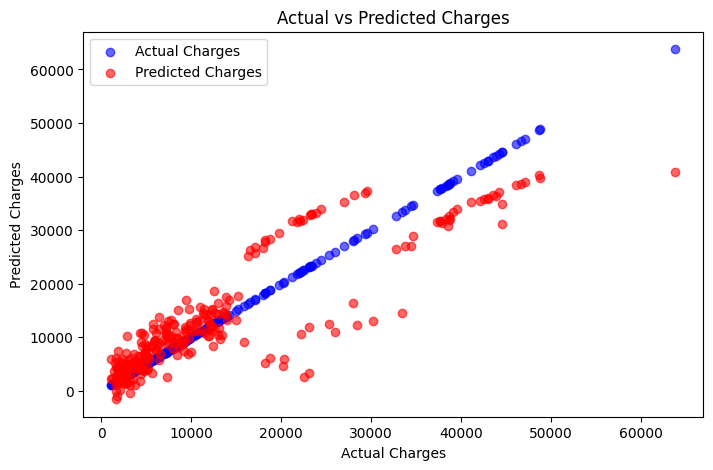

In [21]:
plt.figure(figsize=(8,5))

# Actual Charges
plt.scatter(
    y_test,
    y_test,
    color="blue",
    label="Actual Charges",
    alpha=0.6
)

# Predicted Charges
plt.scatter(
    y_test,
    y_pred_lr,
    color="red",
    label="Predicted Charges",
    alpha=0.6
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.legend()

plt.show()

**7. Menggunakan Model SVR dan Hyperparameter Tuning**

Membuat model **Support Vector Regression (SVR)** dengan kernel RBF, melatih model menggunakan data latih, melakukan prediksi pada data uji, lalu menghitung nilai evaluasi R², MSE, dan MAE. Hasil kedua model kemudian dibandingkan dalam bentuk tabel.


In [17]:
svr_model = SVR(
    kernel="rbf",
    C=100,
    gamma=0.1
)

svr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svr = svr_model.predict(
    X_test_scaled
)

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

mse_svr = mean_squared_error(
    y_test,
    y_pred_svr
)

mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)


print("R-Squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

R-Squared : 0.26972290285581657
MSE       : 113374592.96912912
MAE       : 5695.156518407609


In [18]:
hasil = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "SVR"
    ],
    "R2 Score": [
        r2_lr,
        r2_svr
    ],
    "MSE": [
        mse_lr,
        mse_svr
    ],
    "MAE": [
        mae_lr,
        mae_svr
    ]
})

hasil

,Model,R2 Score,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR,0.269723,1.133746e+08,5695.156518


Melakukan visualisasi hubungan antara BMI dan biaya medis berdasarkan status merokok.

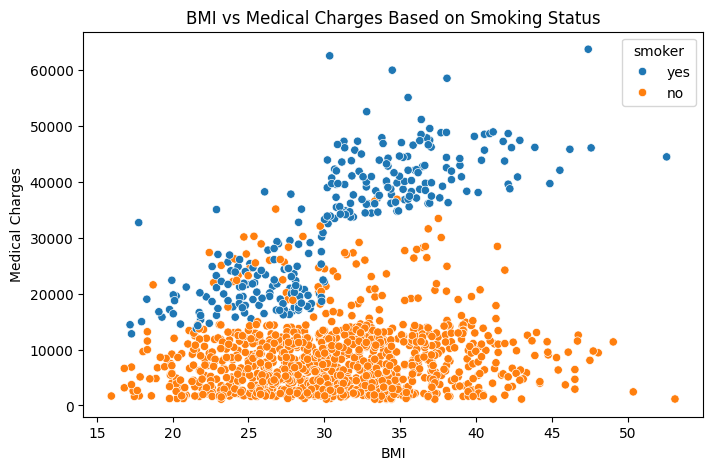

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Medical Charges Based on Smoking Status")

plt.xlabel("BMI")
plt.ylabel("Medical Charges")

plt.show()